# KPI Generation untuk Sales Planner S&OP Simulation

Notebook ini menghasilkan seluruh atribut/kolom KPI berdasarkan panduan `kpis.md`
menggunakan data historis `df_history_display_all_players.csv`.

**KPI yang dihasilkan:**
- Revenue Growth, Gross Margin, Operating Profit
- Market Share, MS Momentum, Relative Price Index
- Service Level, Stockout Rate, Fill Rate
- Forecast Accuracy (MAPE), Forecast Bias
- Inventory Turnover, Price Elasticity
- Competitive Pressure Score (CPS), Pricing Power Indicator (PPI)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('✅ Libraries loaded')


✅ Libraries loaded


In [2]:
df = pd.read_csv('../df_history_display_all_players.csv')
df['month'] = df['month'].astype(int)
df = df.sort_values(['team_name', 'month']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Teams ({df["team_name"].nunique()}): {df["team_name"].unique().tolist()}')
print(f'Month range: {df["month"].min()} - {df["month"].max()}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)


Shape: (144, 26)
Teams (12): ['AI Team', 'Team 1A', 'Team 1B', 'Team 2A', 'Team 2B', 'Team 3A', 'Team 4A', 'Team 4B', 'Team 5A', 'Team 5B', 'Team 6A', 'Team 6B']
Month range: 1 - 12
Columns: ['team_name', 'team_id', 'month', 'total_market', 'competitor_demand', 'firm_demand', 'competitor_price', 'beginning_inventory', 'arrival_qty', 'units_sold', 'ending_inventory', 'in_transit', 'production_order', 'pipeline_units', 'months_of_cover', 'forecast_error', 'service_level', 'revenue_amt', 'cogs_amt', 'inventory_holding_amt', 'stockout_penalty_amt', 'forecast_made', 'price', 'ai_price', 'ai_forecast_qty', 'ai_production_order']


,team_name,team_id,month,total_market,competitor_demand,firm_demand,competitor_price,beginning_inventory,arrival_qty,units_sold,...,service_level,revenue_amt,cogs_amt,inventory_holding_amt,stockout_penalty_amt,forecast_made,price,ai_price,ai_forecast_qty,ai_production_order
0,AI Team,13,1,66.0,29,37,100.0,100,0,37,...,1.0,3700.0,1850.0,630.0,0.0,33,100.0,100.0,33,50
1,AI Team,13,2,84.0,41,43,90.0,63,0,43,...,1.0,4300.0,2150.0,200.0,0.0,37,100.0,100.0,37,50
2,AI Team,13,3,104.0,52,52,90.0,20,50,52,...,1.0,5200.0,2600.0,180.0,0.0,49,100.0,100.0,49,100


## Section 2 — Feature Engineering (KPI Baru)

Menghitung seluruh KPI berdasarkan formulasi di `kpis.md`.


In [3]:
df['unit_cost'] = np.where(
    df['units_sold'] > 0,
    df['cogs_amt'] / df['units_sold'],
    np.nan
)
print('✅ unit_cost computed')


✅ unit_cost computed


In [4]:
df['revenue_growth'] = df.groupby('team_name')['revenue_amt'].pct_change()
df['revenue_growth'] = df['revenue_growth'].replace([np.inf, -np.inf], np.nan)
print('✅ Revenue Growth computed')


✅ Revenue Growth computed


In [5]:
df['gross_margin'] = (df['revenue_amt'] - df['cogs_amt']) / df['revenue_amt']
print('✅ Gross Margin computed')


✅ Gross Margin computed


In [6]:
df['operating_profit'] = (
    df['revenue_amt']
    - df['cogs_amt']
    - df['inventory_holding_amt']
    - df['stockout_penalty_amt']
)
print('✅ Operating Profit computed')


✅ Operating Profit computed


In [7]:
df['market_share'] = df['firm_demand'] / df['total_market']
print('✅ Market Share computed')


✅ Market Share computed


In [8]:
df['ms_momentum'] = df.groupby('team_name')['market_share'].diff()

df['ms_momentum_3mo'] = (
    df.groupby('team_name')['market_share'].transform(lambda x: x - x.shift(3)) / 3
)
print('✅ MS Momentum (1mo & 3mo rolling) computed')


✅ MS Momentum (1mo & 3mo rolling) computed


In [9]:
df['rpi'] = (df['price'] - df['competitor_price']) / df['competitor_price']
print('✅ Relative Price Index computed')


✅ Relative Price Index computed


In [10]:
df['missed_demand'] = (df['firm_demand'] - df['units_sold']).clip(lower=0)

df['stockout_rate'] = np.where(
    df['firm_demand'] > 0,
    df['missed_demand'] / df['firm_demand'],
    np.nan
)

df['fill_rate'] = np.where(
    df['firm_demand'] > 0,
    df['units_sold'] / df['firm_demand'],
    np.nan
)
print('✅ Missed Demand, Stockout Rate, Fill Rate computed')


✅ Missed Demand, Stockout Rate, Fill Rate computed


In [11]:
df['ape'] = np.where(
    df['firm_demand'] > 0,
    (df['forecast_error'].abs() / df['firm_demand']),
    np.nan
)

df['forecast_accuracy'] = 1 - df['ape']

mape_per_team = df.groupby('team_name')['ape'].mean().reset_index()
mape_per_team.columns = ['team_name', 'mape']
mape_per_team['forecast_accuracy_avg'] = 1 - mape_per_team['mape']

bias_per_team = df.groupby('team_name')['forecast_error'].mean().reset_index()
bias_per_team.columns = ['team_name', 'forecast_bias']

df = df.merge(mape_per_team[['team_name', 'mape', 'forecast_accuracy_avg']], on='team_name')
df = df.merge(bias_per_team, on='team_name')

print('✅ Forecast Accuracy (MAPE) and Forecast Bias computed')


✅ Forecast Accuracy (MAPE) and Forecast Bias computed


In [12]:
df['avg_inventory'] = (df['beginning_inventory'] + df['ending_inventory']) / 2

df['inventory_turnover'] = np.where(
    df['avg_inventory'] > 0,
    df['cogs_amt'] / df['avg_inventory'],
    np.nan
)

df['inventory_turnover_annualized'] = df['inventory_turnover'] * 12
print('✅ Inventory Turnover computed')


✅ Inventory Turnover computed


In [13]:
pct_demand = df.groupby('team_name')['firm_demand'].pct_change()
pct_price = df.groupby('team_name')['price'].pct_change()

df['price_elasticity'] = np.where(
    (pct_price != 0) & pct_price.notna() & pct_demand.notna(),
    pct_demand / pct_price,
    np.nan
)
df['price_elasticity'] = df['price_elasticity'].replace([np.inf, -np.inf], np.nan)
print('✅ Price Elasticity computed')


✅ Price Elasticity computed


In [14]:
df['cps'] = df['rpi'] * (-df['ms_momentum'])
print('✅ Competitive Pressure Score computed')


✅ Competitive Pressure Score computed


In [15]:
ms_momentum_neg = df['ms_momentum'].clip(upper=0)

df['ppi'] = np.where(
    (1 + ms_momentum_neg.abs()) != 0,
    (df['gross_margin'] * df['service_level']) / (1 + ms_momentum_neg.abs()),
    np.nan
)
print('✅ Pricing Power Indicator computed')


✅ Pricing Power Indicator computed


### Preview Data dengan Semua KPI


In [16]:
kpi_cols = [
    'team_name', 'month',
    'revenue_amt', 'revenue_growth',
    'gross_margin', 'operating_profit',
    'market_share', 'ms_momentum', 'ms_momentum_3mo',
    'rpi',
    'service_level', 'stockout_rate', 'fill_rate',
    'missed_demand',
    'forecast_accuracy', 'forecast_accuracy_avg', 'forecast_bias',
    'months_of_cover', 'inventory_turnover', 'inventory_turnover_annualized',
    'price_elasticity',
    'cps', 'ppi',
]

df_kpi = df[kpi_cols].copy()
display(df_kpi.head(10))
print(f'\nTotal rows: {len(df_kpi)}')


,team_name,month,revenue_amt,revenue_growth,gross_margin,operating_profit,market_share,ms_momentum,ms_momentum_3mo,rpi,...,missed_demand,forecast_accuracy,forecast_accuracy_avg,forecast_bias,months_of_cover,inventory_turnover,inventory_turnover_annualized,price_elasticity,cps,ppi
0,AI Team,1,3700.0,NaN,0.500000,1220.0,0.560606,NaN,NaN,0.000000,...,0,0.891892,0.772872,1.333333,3.424242,22.699387,272.392638,NaN,NaN,NaN
1,AI Team,2,4300.0,0.162162,0.500000,1950.0,0.511905,-0.048701,NaN,0.111111,...,0,0.860465,0.772872,1.333333,3.243243,51.807229,621.686747,NaN,0.005411,0.476780
2,AI Team,3,5200.0,0.209302,0.500000,2420.0,0.500000,-0.011905,NaN,0.111111,...,0,0.942308,0.772872,1.333333,3.428571,136.842105,1642.105263,NaN,0.001323,0.494118
3,AI Team,4,5400.0,0.038462,0.500000,2560.0,0.500000,0.000000,-0.020202,0.111111,...,0,0.870370,0.772872,1.333333,3.508197,168.750000,2025.000000,NaN,-0.000000,0.500000
4,AI Team,5,6500.0,0.203704,0.500000,2760.0,0.485075,-0.014925,-0.008943,0.111111,...,0,0.861538,0.772872,1.333333,3.553571,103.174603,1238.095238,NaN,0.001658,0.492647
5,AI Team,6,7900.0,0.215385,0.500000,3250.0,0.481707,-0.003367,-0.006098,0.111111,...,0,0.873418,0.772872,1.333333,3.188406,66.386555,796.638655,NaN,0.000374,0.498322
6,AI Team,7,11400.0,0.443038,0.473684,5000.0,0.522388,0.040681,0.007463,0.055556,...,20,0.642857,0.772872,1.333333,2.777778,171.428571,2057.142857,-15.443038,-0.002260,0.406015
7,AI Team,8,9200.0,-0.192982,0.456522,2780.0,0.531056,0.008668,0.015327,0.022222,...,71,0.625731,0.772872,1.333333,3.617021,NaN,NaN,-7.011905,-0.000193,0.266972
8,AI Team,9,13650.0,0.483696,0.450549,5390.0,0.489583,-0.041473,0.002625,0.011111,...,38,0.797872,0.772872,1.333333,3.539823,NaN,NaN,-9.146199,0.000461,0.345166
9,AI Team,10,13320.0,-0.024176,0.444444,400.0,0.490066,0.000483,-0.010774,0.000000,...,0,0.506757,0.772872,1.333333,3.402715,26.811594,321.739130,19.361702,-0.000000,0.444444



Total rows: 144


In [17]:
null_counts = df_kpi.isnull().sum()
null_counts[null_counts > 0]


revenue_growth                   13
gross_margin                      1
ms_momentum                      12
ms_momentum_3mo                  36
inventory_turnover               20
inventory_turnover_annualized    20
price_elasticity                 42
cps                              12
ppi                              13
dtype: int64

## Section 3 — Aggregate KPI per Team


In [18]:
summary = df.groupby('team_name').agg({
    'revenue_amt': 'sum',
    'operating_profit': 'sum',
    'gross_margin': 'mean',
    'service_level': 'mean',
    'stockout_rate': 'mean',
    'revenue_growth': 'mean',
    'market_share': 'mean',
    'rpi': 'mean',
    'mape': 'first',
    'forecast_accuracy_avg': 'first',
    'forecast_bias': 'first',
    'inventory_turnover': 'mean',
    'inventory_turnover_annualized': 'mean',
    'price_elasticity': 'mean',
    'cps': 'mean',
    'ppi': 'mean',
    'months_of_cover': 'mean',
}).reset_index().round(4)

summary.columns = [
    'team_name',
    'total_revenue',
    'total_profit',
    'avg_gross_margin',
    'avg_service_level',
    'avg_stockout_rate',
    'avg_revenue_growth',
    'avg_market_share',
    'avg_rpi',
    'mape',
    'avg_forecast_accuracy',
    'avg_forecast_bias',
    'avg_inventory_turnover',
    'avg_inv_turnover_annualized',
    'avg_price_elasticity',
    'avg_cps',
    'avg_ppi',
    'avg_months_of_cover',
]

display(summary)
print(f'\n✅ Summary table: {summary.shape[0]} teams x {summary.shape[1]} metrics')


,team_name,total_revenue,total_profit,avg_gross_margin,avg_service_level,avg_stockout_rate,avg_revenue_growth,avg_market_share,avg_rpi,mape,avg_forecast_accuracy,avg_forecast_bias,avg_inventory_turnover,avg_inv_turnover_annualized,avg_price_elasticity,avg_cps,avg_ppi,avg_months_of_cover
0,AI Team,116562.0,35132.0,0.4741,0.9367,0.0633,0.1813,0.5133,0.0500,0.2271,0.7729,1.3333,79.3603,952.3235,-4.4546,0.0008,0.4353,3.5104
1,Team 1A,95680.0,32630.0,0.4435,0.9008,0.0992,0.2292,0.4741,0.0692,0.1883,0.8117,19.0833,99.2403,1190.8837,-5.0938,0.0075,0.3835,3.1103
2,Team 1B,76149.0,38989.0,0.5441,0.8445,0.1555,0.0755,0.3453,0.2927,0.3296,0.6704,13.9167,154.3156,1851.7869,-1.6274,0.0570,0.4784,2.6457
3,Team 2A,95626.0,24916.0,0.3911,0.9490,0.0510,0.1606,0.5020,0.0760,0.2091,0.7909,11.1667,154.7881,1857.4571,-2.5852,0.0096,0.3445,3.6908
4,Team 2B,94985.0,4895.0,0.2404,0.9885,0.0115,0.1851,0.5562,0.0290,0.3469,0.6531,-11.8333,286.6788,3440.1461,-1.6073,0.0290,0.2057,3.5864
5,Team 3A,123634.0,44754.0,0.4964,0.9497,0.0503,0.2087,0.5082,0.0581,0.2277,0.7723,9.9167,112.7843,1353.4113,-21.7349,0.0061,0.4593,3.4156
6,Team 4A,93912.0,35342.0,0.4667,0.7966,0.2034,0.2865,0.4897,0.0290,0.1757,0.8243,20.2500,112.1247,1345.4963,4.0472,0.0078,0.3435,2.4082
7,Team 4B,101445.0,28195.0,0.3834,0.9526,0.0474,0.1740,0.5261,0.0476,0.1805,0.8195,9.0000,235.4379,2825.2547,-4.1922,0.0067,0.3441,2.9879
8,Team 5A,99909.0,27409.0,0.3868,0.9721,0.0279,0.1572,0.5017,0.0686,0.1539,0.8461,4.8333,226.8527,2722.2329,-4.1450,0.0053,0.3587,3.1789
9,Team 5B,118172.0,55122.0,0.5146,0.9372,0.0628,0.1745,0.4693,0.0910,0.2053,0.7947,10.1667,110.9115,1330.9382,-1.8926,0.0120,0.4617,2.7548



✅ Summary table: 12 teams x 18 metrics


## Section 4 — Visualizations


### 4.1 — Revenue Trend per Team


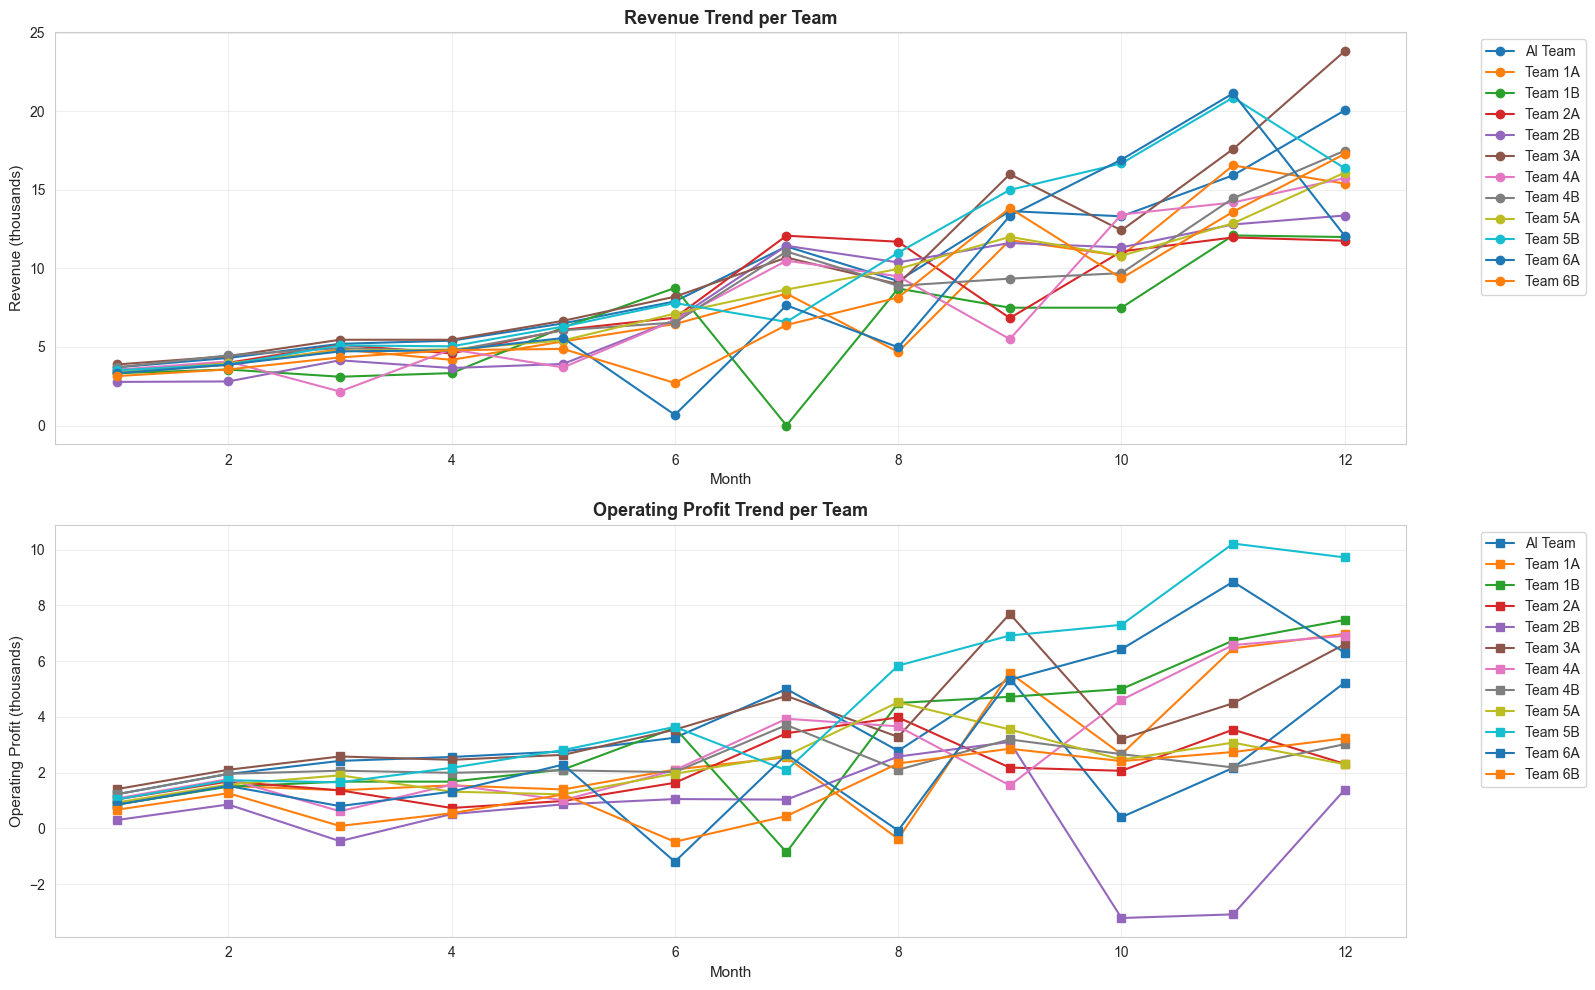

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for team in df['team_name'].unique():
    tdf = df[df['team_name'] == team]
    axes[0].plot(tdf['month'], tdf['revenue_amt'] / 1000, marker='o', label=team, linewidth=1.5)

axes[0].set_title('Revenue Trend per Team', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (thousands)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

for team in df['team_name'].unique():
    tdf = df[df['team_name'] == team]
    axes[1].plot(tdf['month'], tdf['operating_profit'] / 1000, marker='s', label=team, linewidth=1.5)

axes[1].set_title('Operating Profit Trend per Team', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Operating Profit (thousands)')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 4.2 — Gross Margin & Market Share Trend


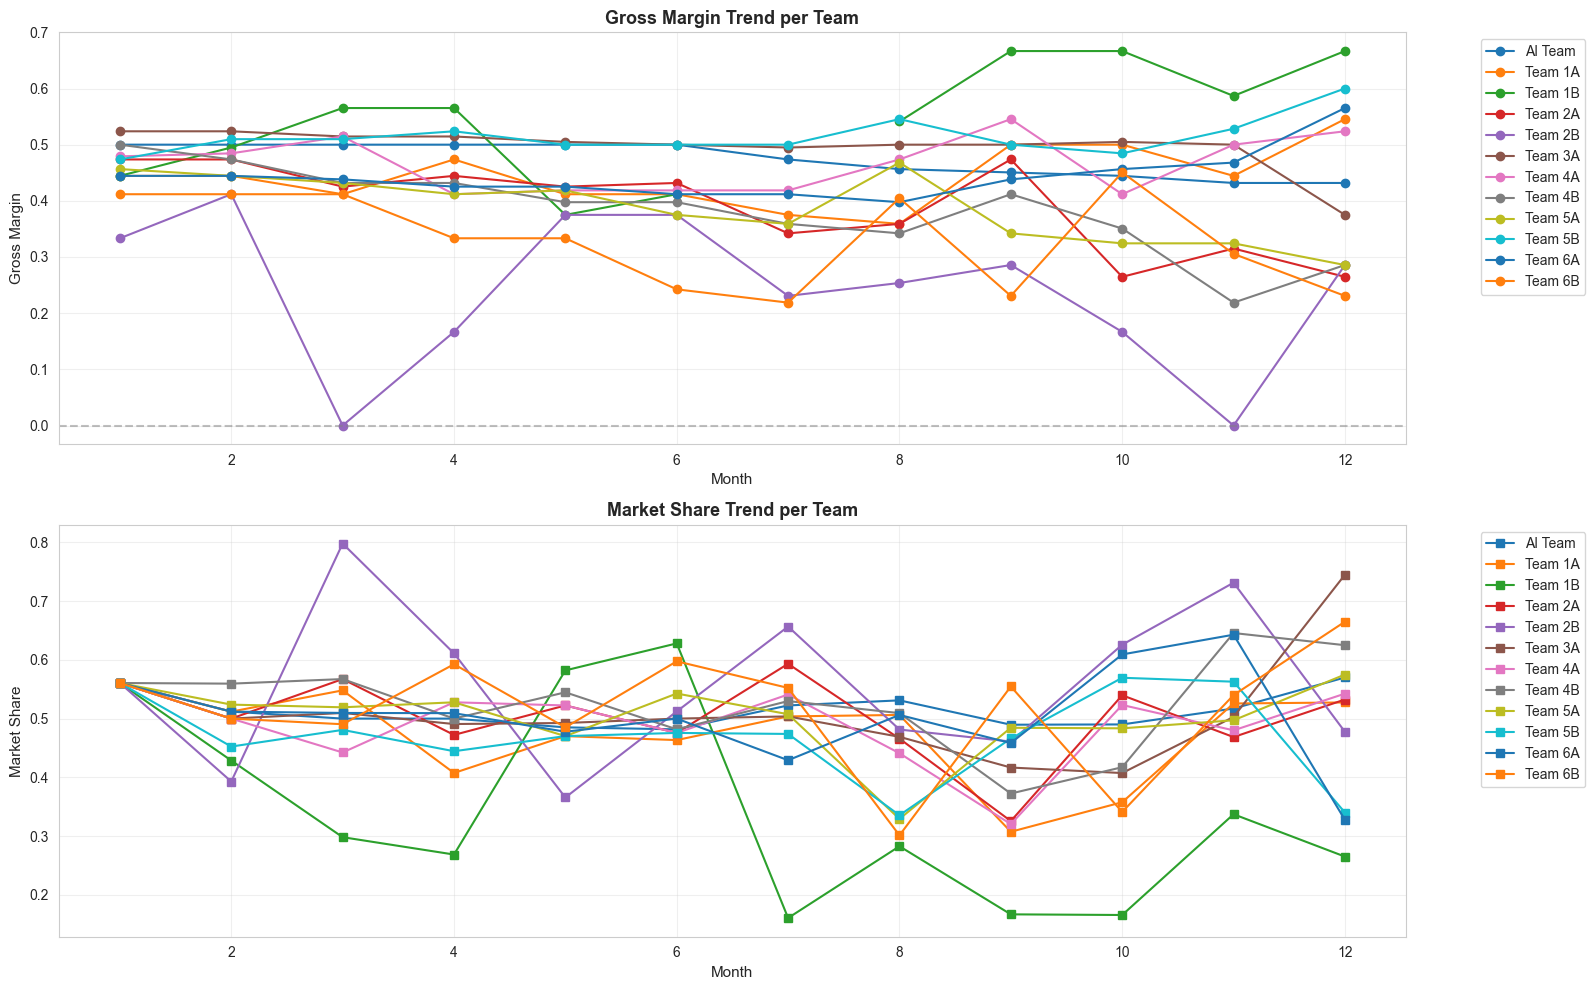

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for team in df['team_name'].unique():
    tdf = df[df['team_name'] == team]
    axes[0].plot(tdf['month'], tdf['gross_margin'], marker='o', label=team, linewidth=1.5)

axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Gross Margin Trend per Team', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Gross Margin')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

for team in df['team_name'].unique():
    tdf = df[df['team_name'] == team]
    axes[1].plot(tdf['month'], tdf['market_share'], marker='s', label=team, linewidth=1.5)

axes[1].set_title('Market Share Trend per Team', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Market Share')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 4.3 — Service Level & Stockout Rate


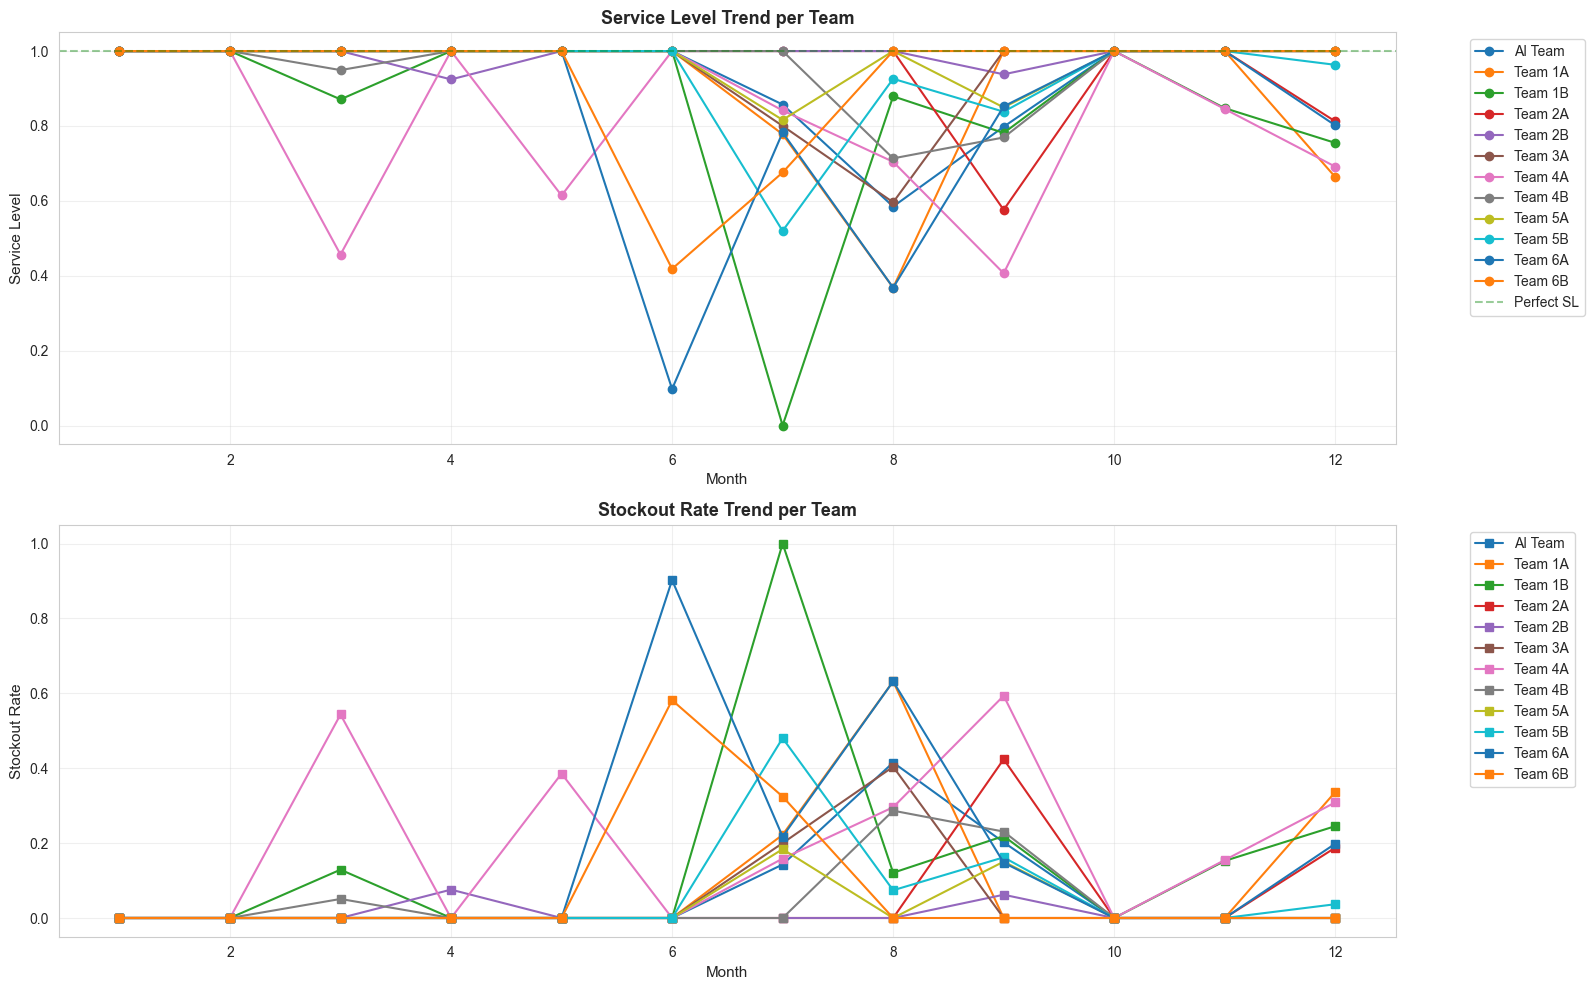

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for team in df['team_name'].unique():
    tdf = df[df['team_name'] == team]
    axes[0].plot(tdf['month'], tdf['service_level'], marker='o', label=team, linewidth=1.5)

axes[0].axhline(y=1.0, color='green', linestyle='--', alpha=0.4, label='Perfect SL')
axes[0].set_title('Service Level Trend per Team', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Service Level')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

for team in df['team_name'].unique():
    tdf = df[df['team_name'] == team]
    axes[1].plot(tdf['month'], tdf['stockout_rate'], marker='s', label=team, linewidth=1.5)

axes[1].set_title('Stockout Rate Trend per Team', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Stockout Rate')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 4.4 — Correlation Heatmap Antar KPI


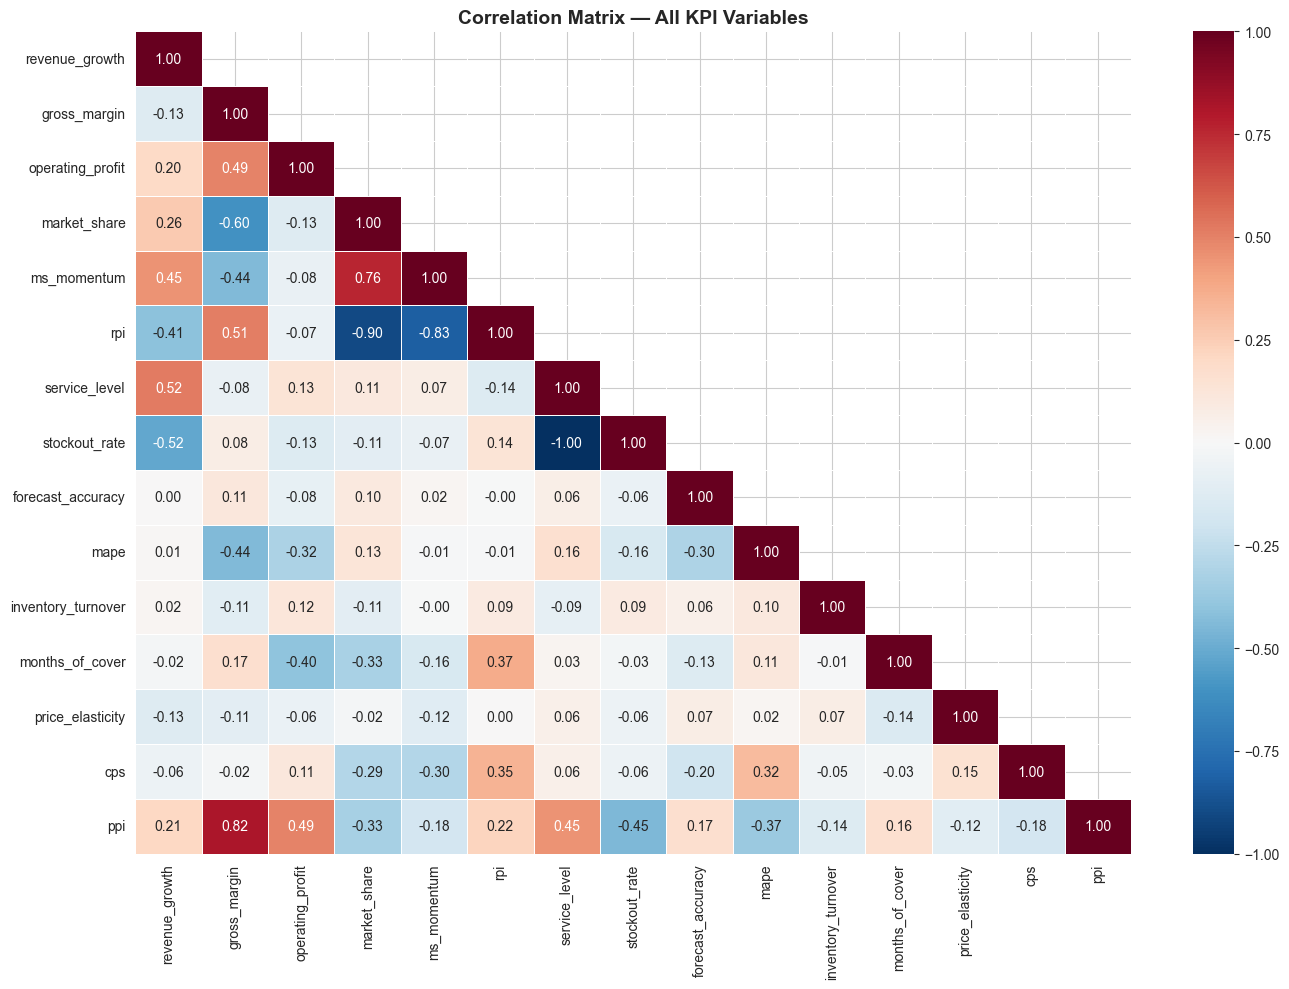

In [22]:
kpi_corr_cols = [
    'revenue_growth', 'gross_margin', 'operating_profit',
    'market_share', 'ms_momentum', 'rpi',
    'service_level', 'stockout_rate',
    'forecast_accuracy', 'mape',
    'inventory_turnover', 'months_of_cover',
    'price_elasticity', 'cps', 'ppi',
]

corr_df = df[kpi_corr_cols].dropna()
corr_matrix = corr_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix — All KPI Variables', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


### 4.5 — Forecast Accuracy & Bias per Team (Bar Chart)


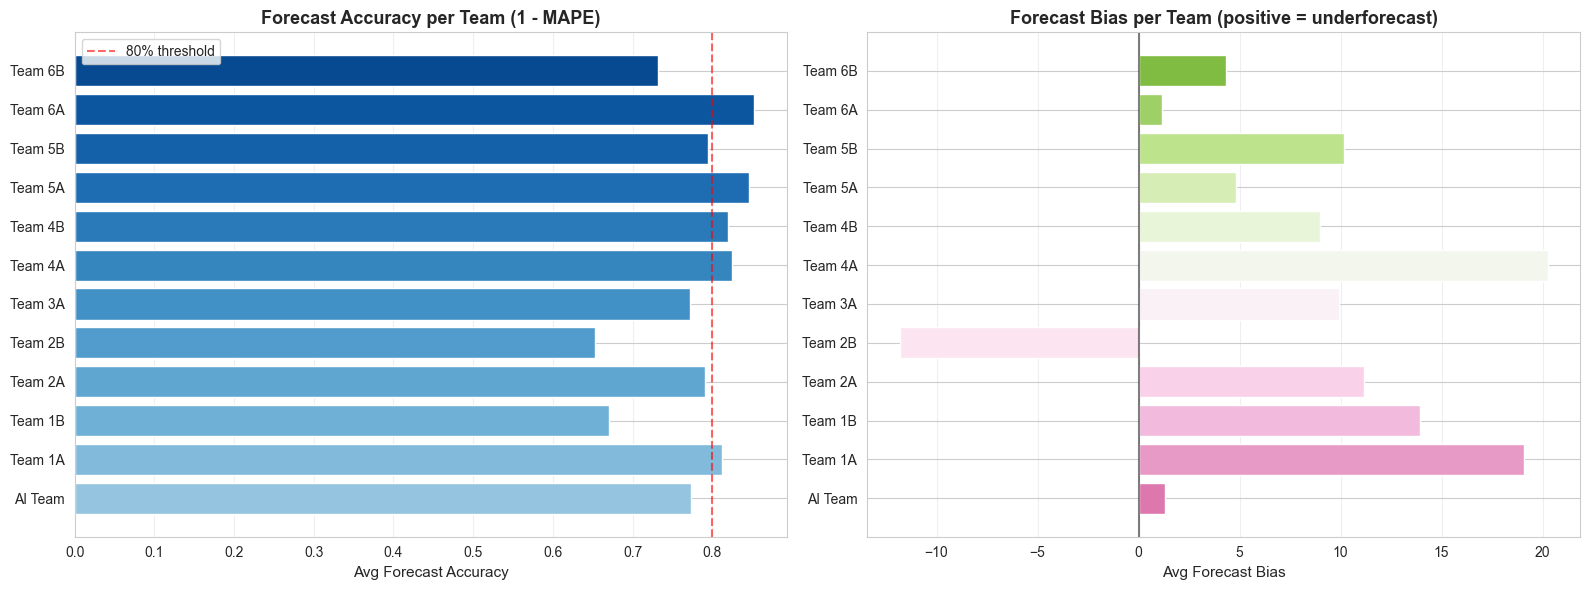

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_acc = plt.cm.Blues(np.linspace(0.4, 0.9, len(summary)))
axes[0].barh(summary['team_name'], summary['avg_forecast_accuracy'], color=colors_acc)
axes[0].axvline(x=0.8, color='red', linestyle='--', alpha=0.6, label='80% threshold')
axes[0].set_xlabel('Avg Forecast Accuracy')
axes[0].set_title('Forecast Accuracy per Team (1 - MAPE)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

colors_bias = plt.cm.PiYG(np.linspace(0.2, 0.8, len(summary)))
bars = axes[1].barh(summary['team_name'], summary['avg_forecast_bias'], color=colors_bias)
axes[1].axvline(x=0, color='black', linestyle='-', alpha=0.5)
axes[1].set_xlabel('Avg Forecast Bias')
axes[1].set_title('Forecast Bias per Team (positive = underforecast)', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


### 4.6 — Price vs Market Share Scatter


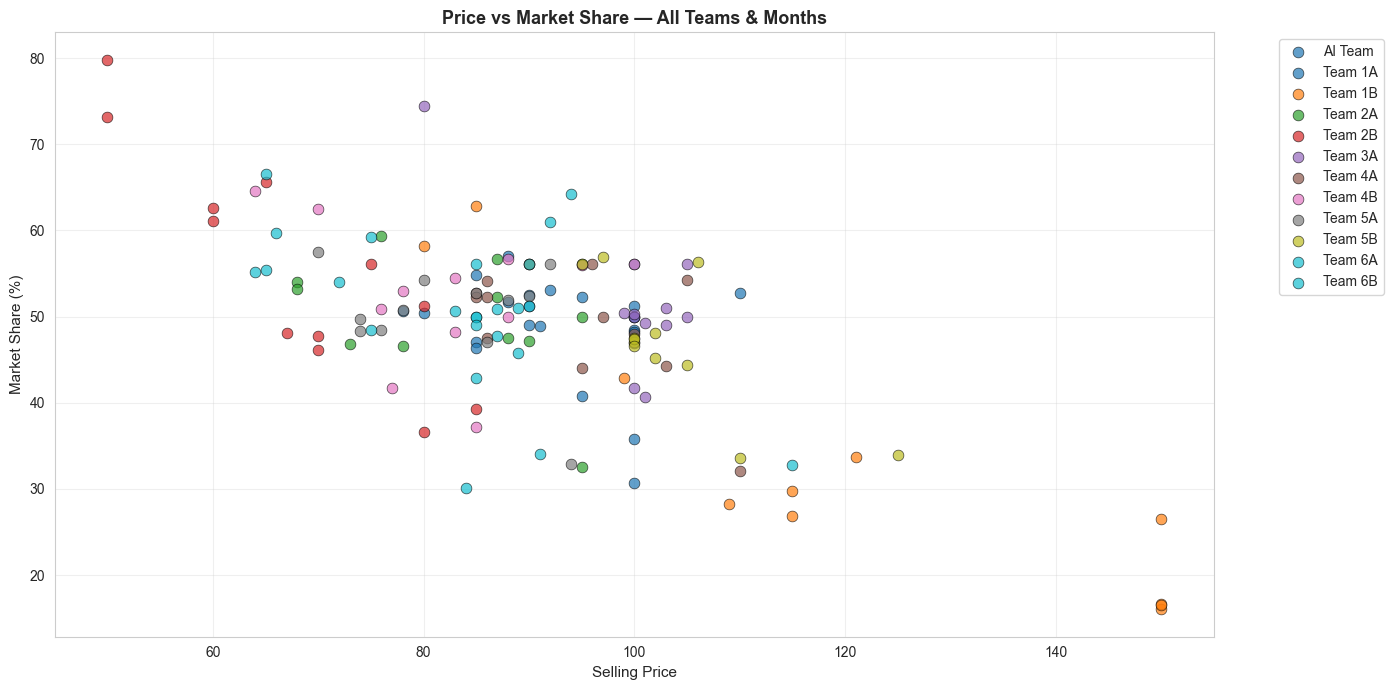

In [24]:
plt.figure(figsize=(14, 7))

teams = df['team_name'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(teams)))

for team, color in zip(teams, colors):
    tdf = df[df['team_name'] == team]
    plt.scatter(tdf['price'], tdf['market_share'] * 100,
                s=60, label=team, color=color, alpha=0.7, edgecolors='k', linewidth=0.5)

plt.xlabel('Selling Price')
plt.ylabel('Market Share (%)')
plt.title('Price vs Market Share — All Teams & Months', fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4.7 — Competitive Pressure & Pricing Power


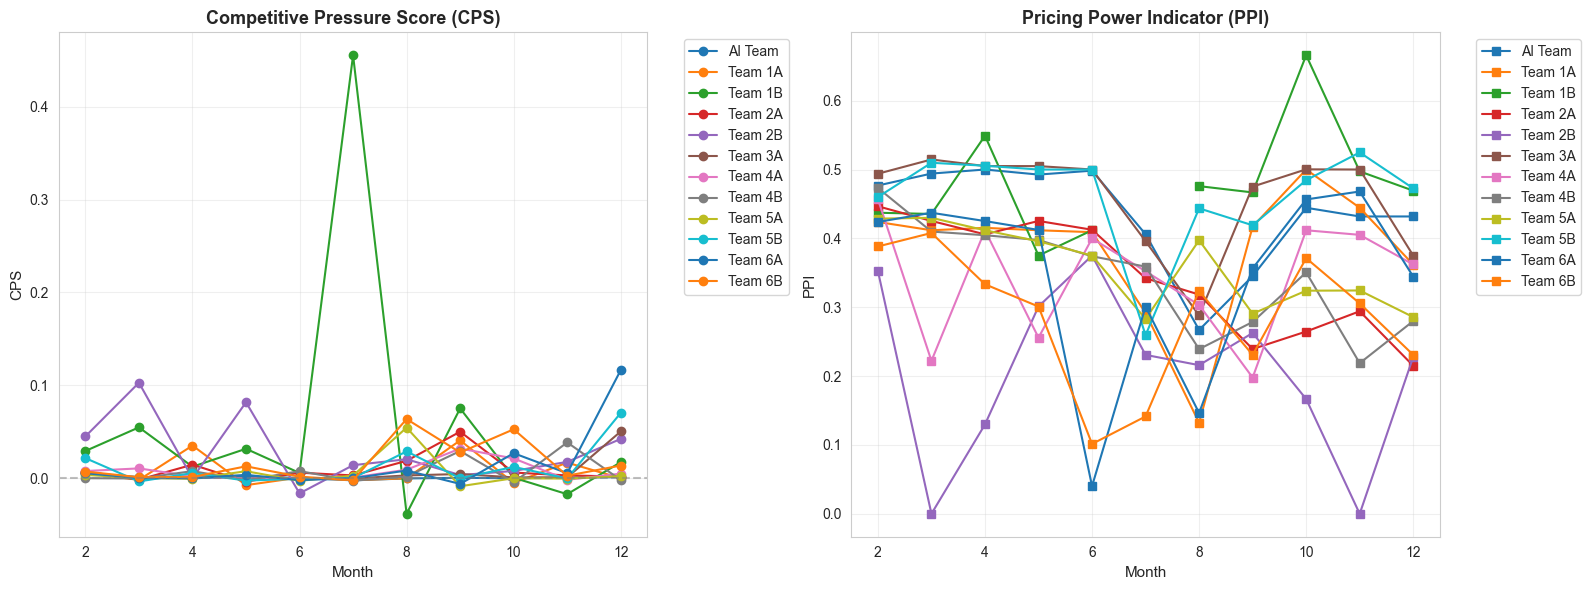

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for team in df['team_name'].unique():
    tdf = df[df['team_name'] == team]
    axes[0].plot(tdf['month'], tdf['cps'], marker='o', label=team, linewidth=1.5)

axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Competitive Pressure Score (CPS)', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('CPS')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

for team in df['team_name'].unique():
    tdf = df[df['team_name'] == team]
    axes[1].plot(tdf['month'], tdf['ppi'], marker='s', label=team, linewidth=1.5)

axes[1].set_title('Pricing Power Indicator (PPI)', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('PPI')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 4.8 — Inventory Turnover & Months of Coverage


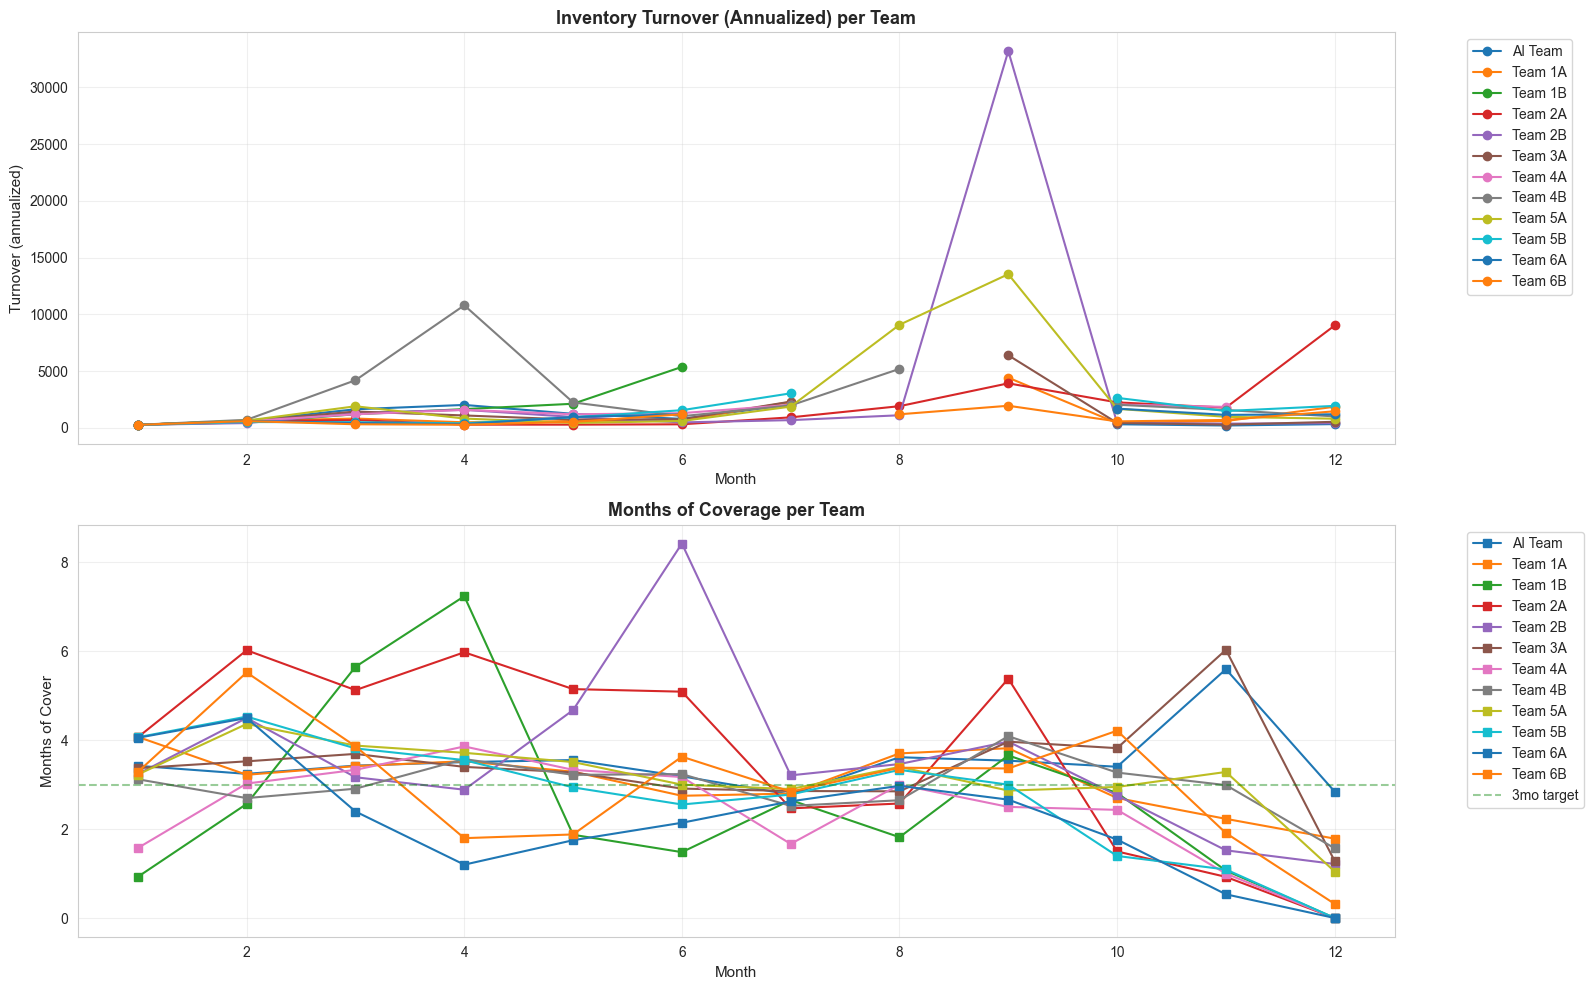

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for team in df['team_name'].unique():
    tdf = df[df['team_name'] == team]
    axes[0].plot(tdf['month'], tdf['inventory_turnover_annualized'], marker='o', label=team, linewidth=1.5)

axes[0].set_title('Inventory Turnover (Annualized) per Team', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Turnover (annualized)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

for team in df['team_name'].unique():
    tdf = df[df['team_name'] == team]
    axes[1].plot(tdf['month'], tdf['months_of_cover'], marker='s', label=team, linewidth=1.5)

axes[1].axhline(y=3, color='green', linestyle='--', alpha=0.4, label='3mo target')
axes[1].set_title('Months of Coverage per Team', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Months of Cover')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Section 5 — Export

Menyimpan enriched dataframe dan summary ke CSV.


In [27]:
output_path = '../df_kpi_all_players.csv'
df.to_csv(output_path, index=False)
print(f'✅ Enriched dataframe saved: {output_path} ({df.shape[0]} rows x {df.shape[1]} cols)')


✅ Enriched dataframe saved: ../df_kpi_all_players.csv (144 rows x 48 cols)


In [28]:
summary_path = '../df_kpi_summary.csv'
summary.to_csv(summary_path, index=False)
print(f'✅ Summary saved: {summary_path} ({summary.shape[0]} teams x {summary.shape[1]} metrics)')


✅ Summary saved: ../df_kpi_summary.csv (12 teams x 18 metrics)


---
**Notebook selesai.** Semua KPI per panduan `kpis.md` telah dihasilkan.
